In [2]:
# Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load Data
DB_PATH = r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\bluestock_mf.db'
RAW_PATH = r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\data\raw'

conn = sqlite3.connect(DB_PATH)
nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
fund_df = pd.read_sql("SELECT * FROM dim_fund", conn)
perf_df = pd.read_sql("SELECT * FROM fact_performance", conn)
conn.close()

bench_df = pd.read_csv(f'{RAW_PATH}/10_benchmark_indices.csv')

nav_df['date'] = pd.to_datetime(nav_df['date'])
bench_df['date'] = pd.to_datetime(bench_df['date'])

print(f"✅ NAV records: {len(nav_df)}")
print(f"✅ Funds: {len(fund_df)}")
print(f"✅ Benchmark: {len(bench_df)}")
print(bench_df['index_name'].unique())
print("\n✅ All data loaded!")

✅ NAV records: 46000
✅ Funds: 40
✅ Benchmark: 8050
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

✅ All data loaded!


✅ Daily returns shape: (1149, 40)
   Date range: 2022-01-04 00:00:00 → 2026-05-29 00:00:00

Sample returns (first 3 funds):
amfi_code   100016  100025  100033
date                              
2022-01-04 -0.0103 -0.0036 -0.0133
2022-01-05  0.0129 -0.0000 -0.0044
2022-01-06 -0.0114 -0.0019 -0.0052
2022-01-07 -0.0012  0.0020 -0.0057
2022-01-10 -0.0086  0.0068  0.0063


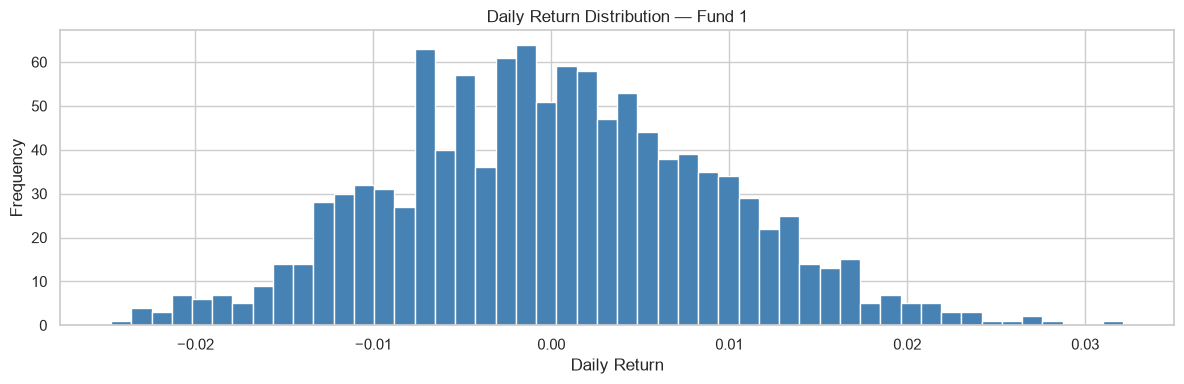

✅ Cell 2: Daily Returns done!


In [3]:
# Cell 2: Daily Returns Calculation
# Pivot: date x amfi_code
nav_pivot = nav_df.pivot_table(index='date', columns='amfi_code', values='nav')

# Daily return = (nav_t / nav_t-1) - 1
daily_returns = nav_pivot.pct_change().dropna()

print(f"✅ Daily returns shape: {daily_returns.shape}")
print(f"   Date range: {daily_returns.index.min()} → {daily_returns.index.max()}")
print(f"\nSample returns (first 3 funds):")
print(daily_returns.iloc[:5, :3].round(4))

# Validate distribution
plt.figure(figsize=(12, 4))
daily_returns.iloc[:, 0].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Daily Return Distribution — Fund 1')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("✅ Cell 2: Daily Returns done!")

In [4]:
# Cell 3: CAGR for 1yr, 3yr, 5yr
def calculate_cagr(nav_series, years):
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    trading_days = years * 252
    if len(nav_series) < trading_days:
        trading_days = len(nav_series)
    nav_end = nav_series.iloc[-1]
    nav_start = nav_series.iloc[-trading_days]
    cagr = (nav_end / nav_start) ** (1/years) - 1
    return round(cagr * 100, 2)

cagr_results = []
for amfi_code in nav_pivot.columns:
    series = nav_pivot[amfi_code].dropna()
    fund_name = fund_df[fund_df['amfi_code']==amfi_code]['scheme_name'].values
    name = fund_name[0] if len(fund_name) > 0 else str(amfi_code)
    cagr_results.append({
        'amfi_code': amfi_code,
        'scheme_name': name,
        'cagr_1yr': calculate_cagr(series, 1),
        'cagr_3yr': calculate_cagr(series, 3),
        'cagr_5yr': calculate_cagr(series, 5)
    })

cagr_df = pd.DataFrame(cagr_results)
print("✅ CAGR Calculated!")
print(cagr_df[['scheme_name','cagr_1yr','cagr_3yr','cagr_5yr']].head(10).to_string())

✅ CAGR Calculated!
                                          scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
0           HDFC Top 100 Fund - Regular Plan - Growth     -3.31     -0.03      2.32
1        HDFC Short Term Debt Fund - Regular - Growth      2.50      4.61      3.91
2  HDFC Mid-Cap Opportunities Fund - Regular - Growth     47.73     33.63     26.07
3       ABSL Frontline Equity Fund - Regular - Growth     45.09     32.53     20.44
4              ABSL Small Cap Fund - Regular - Growth    -24.24     -2.70      6.95
5                 ABSL Liquid Fund - Regular - Growth      6.85      6.08      5.71
6          UTI Nifty 50 Index Fund - Regular - Growth     18.32     17.52     15.88
7                 UTI Mid Cap Fund - Regular - Growth    -13.23     -1.83      1.03
8               UTI Flexi Cap Fund - Regular - Growth     12.73     25.66     14.68
9      Nippon India Large Cap Fund - Regular - Growth     21.78     18.09     20.88


In [5]:
# Cell 4: Sharpe & Sortino Ratio
Rf = 6.5 / 100 / 252  # Daily risk-free rate

sharpe_results = []
for amfi_code in daily_returns.columns:
    returns = daily_returns[amfi_code].dropna()
    if len(returns) < 50:
        continue
    
    # Sharpe Ratio
    excess = returns - Rf
    sharpe = (excess.mean() / returns.std()) * np.sqrt(252)
    
    # Sortino Ratio (only negative returns)
    downside = returns[returns < 0]
    downside_std = downside.std()
    sortino = (excess.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    
    fund_name = fund_df[fund_df['amfi_code']==amfi_code]['scheme_name'].values
    name = fund_name[0] if len(fund_name) > 0 else str(amfi_code)
    
    sharpe_results.append({
        'amfi_code': amfi_code,
        'scheme_name': name,
        'sharpe_ratio': round(sharpe, 3),
        'sortino_ratio': round(sortino, 3)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False)

print("✅ Top 10 Funds by Sharpe Ratio:")
print(sharpe_df[['scheme_name','sharpe_ratio','sortino_ratio']].head(10).to_string())

✅ Top 10 Funds by Sharpe Ratio:
                                           scheme_name  sharpe_ratio  sortino_ratio
34       Mirae Asset Large Cap Fund - Regular - Growth         1.448          2.386
30              Kotak Flexicap Fund - Regular - Growth         1.307          2.364
36       Mirae Asset Tax Saver Fund - Regular - Growth         1.235          2.147
19           SBI Bluechip Fund - Regular Plan - Growth         1.208          2.140
25            ICICI Pru Midcap Fund - Regular - Growth         1.180          2.029
38                  DSP Midcap Fund - Regular - Growth         1.132          1.875
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.094          1.829
9       Nippon India Large Cap Fund - Regular - Growth         1.082          1.850
3        ABSL Frontline Equity Fund - Regular - Growth         1.027          1.800
24           ICICI Pru Bluechip Fund - Direct - Growth         1.027          1.805


In [6]:
# Cell 5: Alpha & Beta vs Nifty 100
# Get Nifty 100 benchmark
nifty100 = bench_df[bench_df['index_name'].str.contains('100', case=False)]
if len(nifty100) == 0:
    nifty100 = bench_df[bench_df['index_name'] == bench_df['index_name'].unique()[0]]

nifty100 = nifty100.set_index('date')['close_value'].sort_index()
nifty100_returns = nifty100.pct_change().dropna()

alpha_beta_results = []
for amfi_code in daily_returns.columns:
    fund_returns = daily_returns[amfi_code].dropna()
    
    # Align dates
    common = fund_returns.index.intersection(nifty100_returns.index)
    if len(common) < 50:
        continue
    
    f_ret = fund_returns[common]
    b_ret = nifty100_returns[common]
    
    # OLS Regression
    slope, intercept, r, p, se = stats.linregress(b_ret, f_ret)
    beta = round(slope, 3)
    alpha = round(intercept * 252 * 100, 3)
    
    fund_name = fund_df[fund_df['amfi_code']==amfi_code]['scheme_name'].values
    name = fund_name[0] if len(fund_name) > 0 else str(amfi_code)
    
    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'scheme_name': name,
        'alpha': alpha,
        'beta': beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print("✅ Alpha & Beta calculated!")
print(alpha_beta_df[['scheme_name','alpha','beta']].head(10).to_string())

# Save
alpha_beta_df.to_csv(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\data\processed\alpha_beta.csv', index=False)
print("\n✅ alpha_beta.csv saved!")

✅ Alpha & Beta calculated!
                                          scheme_name   alpha   beta
0           HDFC Top 100 Fund - Regular Plan - Growth   3.748 -0.058
1        HDFC Short Term Debt Fund - Regular - Growth   4.282  0.001
2  HDFC Mid-Cap Opportunities Fund - Regular - Growth  27.195  0.005
3       ABSL Frontline Equity Fund - Regular - Growth  21.400  0.021
4              ABSL Small Cap Fund - Regular - Growth  10.897 -0.065
5                 ABSL Liquid Fund - Regular - Growth   6.086  0.000
6          UTI Nifty 50 Index Fund - Regular - Growth  17.049 -0.019
7                 UTI Mid Cap Fund - Regular - Growth   2.897 -0.042
8               UTI Flexi Cap Fund - Regular - Growth  16.211  0.017
9      Nippon India Large Cap Fund - Regular - Growth  21.829 -0.008

✅ alpha_beta.csv saved!


In [7]:
# Cell 6: Maximum Drawdown
drawdown_results = []

for amfi_code in nav_pivot.columns:
    series = nav_pivot[amfi_code].dropna()
    if len(series) < 50:
        continue
    
    # Running maximum
    running_max = series.cummax()
    
    # Drawdown = (NAV / running_max) - 1
    drawdown = (series / running_max) - 1
    
    max_dd = drawdown.min()
    worst_date = drawdown.idxmin()
    
    fund_name = fund_df[fund_df['amfi_code']==amfi_code]['scheme_name'].values
    name = fund_name[0] if len(fund_name) > 0 else str(amfi_code)
    
    drawdown_results.append({
        'amfi_code': amfi_code,
        'scheme_name': name,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'worst_date': worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df = drawdown_df.sort_values('max_drawdown_pct')

print("✅ Maximum Drawdown calculated!")
print("\nTop 10 Worst Drawdowns:")
print(drawdown_df[['scheme_name','max_drawdown_pct','worst_date']].head(10).to_string())

✅ Maximum Drawdown calculated!

Top 10 Worst Drawdowns:
                                       scheme_name  max_drawdown_pct worst_date
22       SBI Small Cap Fund - Direct Plan - Growth            -52.57 2025-10-28
17          Axis Small Cap Fund - Regular - Growth            -51.68 2026-05-11
4           ABSL Small Cap Fund - Regular - Growth            -35.45 2026-05-11
39           DSP Small Cap Fund - Regular - Growth            -31.17 2025-01-03
21      SBI Small Cap Fund - Regular Plan - Growth            -28.71 2025-05-14
7              UTI Mid Cap Fund - Regular - Growth            -28.00 2026-04-27
0        HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-09-15
29   Kotak Emerging Equity Fund - Regular - Growth            -24.00 2024-10-17
11  Nippon India Small Cap Fund - Regular - Growth            -23.34 2026-02-20
15            Axis Bluechip Fund - Direct - Growth            -21.75 2023-05-22


In [8]:
# Cell 7: Fund Scorecard (0-100)
# Merge all metrics
scorecard = cagr_df[['amfi_code','scheme_name','cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code','alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(drawdown_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(fund_df[['amfi_code','expense_ratio_pct']], on='amfi_code', how='left')

# Rank each metric (percentile rank 0-100)
scorecard['rank_3yr'] = scorecard['cagr_3yr'].rank(pct=True) * 100
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(pct=True) * 100
scorecard['rank_alpha'] = scorecard['alpha'].rank(pct=True) * 100
scorecard['rank_expense'] = (1 - scorecard['expense_ratio_pct'].rank(pct=True)) * 100
scorecard['rank_drawdown'] = (1 - scorecard['max_drawdown_pct'].rank(pct=True)) * 100

# Composite Score
scorecard['fund_score'] = (
    0.30 * scorecard['rank_3yr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_drawdown']
).round(2)

scorecard = scorecard.sort_values('fund_score', ascending=False)

print("✅ Fund Scorecard:")
print(scorecard[['scheme_name','cagr_3yr','sharpe_ratio','alpha','fund_score']].head(10).to_string())

# Save
scorecard.to_csv(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\data\processed\fund_scorecard.csv', index=False)
print("\n✅ fund_scorecard.csv saved!")

✅ Fund Scorecard:
                                           scheme_name  cagr_3yr  sharpe_ratio   alpha  fund_score
25            ICICI Pru Midcap Fund - Regular - Growth     30.21         1.180  29.264       83.88
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth     33.63         1.094  27.195       81.38
16                 Axis Midcap Fund - Regular - Growth     36.07         0.998  26.077       80.12
21          SBI Small Cap Fund - Regular Plan - Growth     27.81         0.945  30.337       78.25
34       Mirae Asset Large Cap Fund - Regular - Growth     31.28         1.448  26.984       77.88
30              Kotak Flexicap Fund - Regular - Growth     25.66         1.307  27.330       75.75
39               DSP Small Cap Fund - Regular - Growth     25.03         0.950  30.058       73.56
24           ICICI Pru Bluechip Fund - Direct - Growth     28.37         1.027  21.195       73.19
19           SBI Bluechip Fund - Regular Plan - Growth     27.73         1.208  23.201     

Available benchmarks: <StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


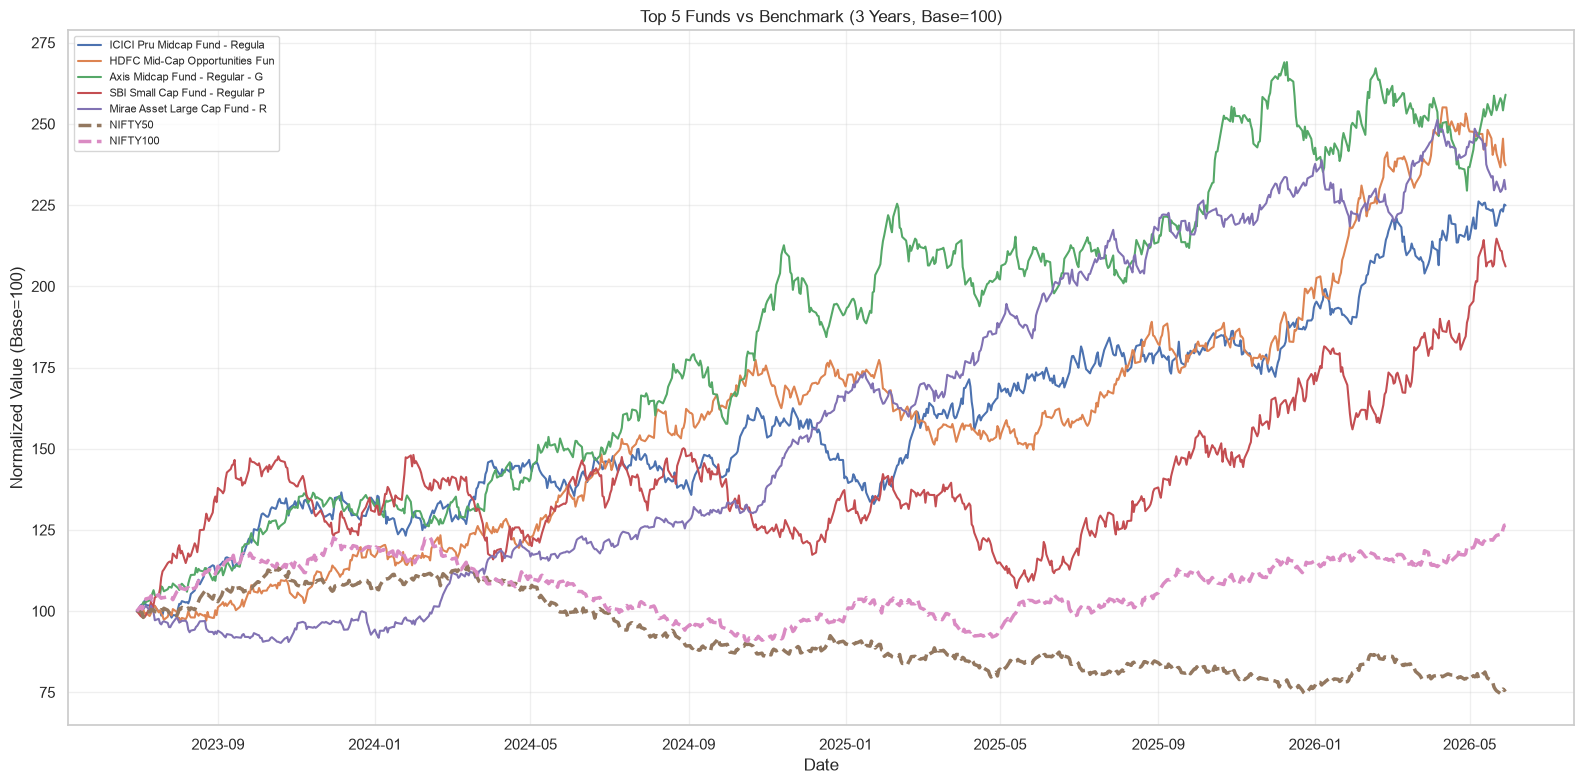

✅ Chart: Benchmark Comparison done!


In [9]:
# Cell 8: Benchmark Comparison Chart
# Get top 5 funds by score
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5)['scheme_name'].tolist()

# Filter last 3 years
three_years_ago = pd.Timestamp.now() - pd.DateOffset(years=3)
nav_3yr = nav_pivot[nav_pivot.index >= three_years_ago]

# Normalize to 100 (base = first value)
nav_normalized = (nav_3yr[top5_codes] / nav_3yr[top5_codes].iloc[0]) * 100

# Benchmark normalize
bench_pivot = bench_df.set_index('date')
benchmarks = bench_df['index_name'].unique()
print("Available benchmarks:", benchmarks)

plt.figure(figsize=(16, 8))

# Plot top 5 funds
for i, code in enumerate(top5_codes):
    if code in nav_normalized.columns:
        plt.plot(nav_normalized.index,
                nav_normalized[code],
                label=top5_names[i][:30],
                linewidth=1.5)

# Plot benchmarks
for bench_name in benchmarks[:2]:
    b = bench_df[bench_df['index_name']==bench_name].set_index('date')['close_value']
    b = b[b.index >= three_years_ago]
    if len(b) > 0:
        b_norm = (b / b.iloc[0]) * 100
        plt.plot(b_norm.index, b_norm,
                label=bench_name,
                linewidth=2.5,
                linestyle='--')

plt.title('Top 5 Funds vs Benchmark (3 Years, Base=100)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base=100)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\benchmark_comparison.png', dpi=150)
plt.show()
print("✅ Chart: Benchmark Comparison done!")

In [11]:
# Cell 9: Tracking Error
tracking_errors = []

for bench_name in benchmarks[:2]:
    b = bench_df[bench_df['index_name']==bench_name].set_index('date')['close_value']
    b_returns = b.pct_change().dropna()
    
    for i, code in enumerate(top5_codes):
        if code not in daily_returns.columns:
            continue
        f_ret = daily_returns[code].dropna()
        common = f_ret.index.intersection(b_returns.index)
        if len(common) < 50:
            continue
        diff = f_ret[common] - b_returns[common]
        tracking_error = diff.std() * np.sqrt(252) * 100
        tracking_errors.append({
            'scheme_name': top5_names[i][:30],
            'benchmark': bench_name,
            'tracking_error_pct': round(tracking_error, 3)
        })

te_df = pd.DataFrame(tracking_errors)
print("✅ Tracking Error:")
print(te_df.to_string())
print("\n🎉 Day 4 Performance Analytics Complete!")

✅ Tracking Error:
                      scheme_name benchmark  tracking_error_pct
0  ICICI Pru Midcap Fund - Regula   NIFTY50              23.312
1  HDFC Mid-Cap Opportunities Fun   NIFTY50              22.976
2  Axis Midcap Fund - Regular - G   NIFTY50              23.707
3  SBI Small Cap Fund - Regular P   NIFTY50              27.803
4  Mirae Asset Large Cap Fund - R   NIFTY50              19.400
5  ICICI Pru Midcap Fund - Regula  NIFTY100              23.197
6  HDFC Mid-Cap Opportunities Fun  NIFTY100              22.870
7  Axis Midcap Fund - Regular - G  NIFTY100              23.765
8  SBI Small Cap Fund - Regular P  NIFTY100              28.388
9  Mirae Asset Large Cap Fund - R  NIFTY100              18.966

🎉 Day 4 Performance Analytics Complete!
